In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
x = np.arange(1,101)
x

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [4]:
y = (x**2) + np.random.normal(0,50,100)
y

array([-4.08254956e+01,  3.80340347e+01, -9.84186195e+00, -2.09067104e+01,
       -5.51514573e+01,  9.44497427e+01,  5.64492832e+01,  5.29669625e+01,
        8.82833983e+01,  1.77658825e+01,  9.00895962e+01,  1.37961354e+02,
        1.37033698e+02,  1.02871026e+02,  1.72212451e+02,  2.04363718e+02,
        2.81819906e+02,  2.79955963e+02,  3.53666923e+02,  4.55417243e+02,
        4.57226258e+02,  5.59320679e+02,  5.12964594e+02,  4.79641265e+02,
        5.40616565e+02,  7.01267160e+02,  7.84855073e+02,  8.01069417e+02,
        9.22901918e+02,  8.98880707e+02,  9.45190778e+02,  1.06813997e+03,
        1.12944923e+03,  1.15117730e+03,  1.11861391e+03,  1.27800436e+03,
        1.42742273e+03,  1.40295157e+03,  1.53018418e+03,  1.69703822e+03,
        1.78779539e+03,  1.79771361e+03,  1.91411904e+03,  1.94762992e+03,
        2.00605220e+03,  2.15481597e+03,  2.25934119e+03,  2.30710669e+03,
        2.41858371e+03,  2.41211148e+03,  2.53814307e+03,  2.71482993e+03,
        2.84585300e+03,  

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
x_train = pd.DataFrame({"X": x_train})
x_test = pd.DataFrame({"X": x_test})

In [16]:
comp = {
    "Degree": [],
    "RMSE": [],
}
for i in range(1,7):
    poly = PolynomialFeatures(degree=i)
    comp["Degree"].append(i)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.fit_transform(x_test)
    model = LinearRegression()
    model.fit(x_train_poly, y_train)
    comp["RMSE"].append(
        root_mean_squared_error(
            y_test,
            model.predict(x_test_poly)
        )
    )
comp_df = pd.DataFrame(comp)

Text(0.5, 1.0, 'Comparison between degree and RMSE for Polynomial Regression')

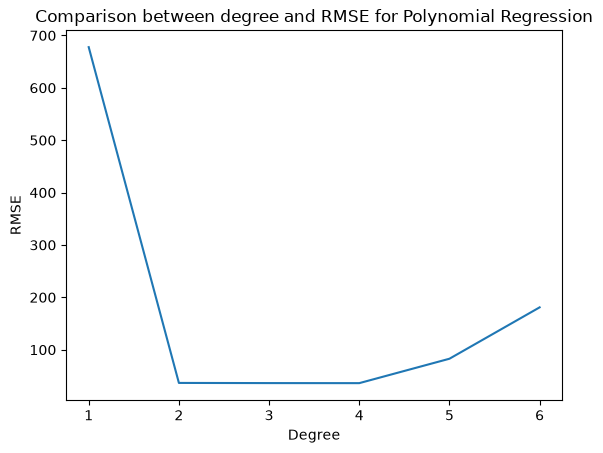

In [17]:
plt.plot(
    comp_df["Degree"],
    comp_df["RMSE"]
)
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.title("Comparison between degree and RMSE for Polynomial Regression")

In [23]:
print(comp_df.loc[comp_df["RMSE"].idxmin()])

Degree     4.000000
RMSE      36.179874
Name: 3, dtype: float64
